In [1]:
# !pip install segmentation-models-pytorch
# !pip install torchmetrics
# !pip install mlflow[databricks]

In [2]:
import os

# Replace with your actual workspace URL and token
# os.environ['DATABRICKS_HOST'] = ""
# os.environ['DATABRICKS_TOKEN'] = ""


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# from torchmetrics.segmentation import DiceScore
# from torchmetrics.segmentation import MeanIoU

from tqdm import tqdm
import json

# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map, alpha=0.45):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def show_overlay_with_labels(image, mask, label_dict, alpha=0.45, min_pixels=20):
    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    # image = cv2.imread(image_path)
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    overlay = create_color_overlay(mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Overlay con clases anatómicas")
    plt.axis("off")
    plt.show()

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# dataset = '/content/drive/MyDrive/Documentos/UniAndes/MAIA/2026-12/Proyecto Despluiegue de Soluciones/Proyecto/Scoliosis_Dataset'
# indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))

In [7]:
# dataset = 'Scoliosis_Dataset'
project_path = 'C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA'
dataset = os.path.join(project_path,'Scoliosis_Dataset')
indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))
data_split = 'C:/Users/juanm/PycharmProjects/Segmentacion_semantica_columna/notebooks/medsam_pipeline/data_splits\splits_estratificados_medsam.csv'
data_split = pd.read_csv(data_split)

In [8]:
with open(dataset+os.sep+'diccionario_etiquetas_T1_T12_L1_L5.json', 'r') as f:
    dic_labels = json.load(f)

color_label = dic_labels['mascara_multiclase_color_rgb']

In [9]:
# imagenes = pd.DataFrame(columns=['image_path', 'mask_path', 'id_paciente'])
# imagenes['image_path'] = dataset +os.sep + indice['grupo'] + os.sep + indice['imagen']
# imagenes['mask_path'] = dataset + os.sep + indice['ruta_mascara_multiclase_id_png']
# imagenes['id_paciente'] = indice['id_paciente']
# masks_path = masks_path.apple(dataset, indice['grupo'], indice['ruta_mascara_multiclase_id_png'])

In [10]:
# imagenes

In [11]:
train = data_split[data_split['split'] == 'train']
val = data_split[data_split['split'] == 'val']
test = data_split[data_split['split'] == 'test']

In [12]:
train_img = project_path+os.sep+train['image_relpath'].reset_index(drop=True)
train_mask = project_path+os.sep+train['mask_relpath'].reset_index(drop=True)
val_img = project_path+os.sep+val['image_relpath'].reset_index(drop=True)
val_mask = project_path+os.sep+val['mask_relpath'].reset_index(drop=True)
test_img = project_path+os.sep+test['image_relpath'].reset_index(drop=True)
test_mask = project_path+os.sep+test['mask_relpath'].reset_index(drop=True)

In [13]:
print(f'Train: {train_img.shape} Val: {val_img.shape} Test: {test_img.shape}')

Train: (174,) Val: (37,) Test: (38,)


In [14]:
MODEL_NAME = 'Unet++'
MODEL_PATH = 'modelos'+os.sep+MODEL_NAME+'.pth'
SEED = 42
NUM_EPOCHS = 50
BATCH_SIZE = 4
PATIENCE = 50
STRIDE = 4
LR = 1e-3                   # Learning rate
WD = 1e-4                   # Weight Decay
DROPOUT = None
PATCH_SIZE = 128
NUM_PATCHES = 8
STRIDE = 48
IN_CHANNELS = 3
NUM_CLASSES = 18
TRAIN_ENCODER = True
CENTER_IMAGES = True
CLAHE = True
PERSPECTIVE = True

# LOSS = 'CrossEntropyLoss'
LOSS = 'CombinedLoss'
# LOSS = 'DiceLoss'

# ENCODER_NAME = "resnet34"
# ENCODER_NAME = "resnet152"
ENCODER_NAME = "efficientnet-b7"
# ENCODER_NAME = "mit_b5"
# ENCODER_NAME = "tu-swinv2_small_window16_256"
# ENCODER_NAME = 'tu-sam2_hiera_large'

ENCODER_WEIGHTS = "imagenet"
# ENCODER_WEIGHTS = None

# DECODER_ATTENTION = 'scse'
DECODER_ATTENTION = None

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

if IN_CHANNELS == 1:
  MEAN = 0.44531356896770125
  STD = 0.2692461874154524

# CE_WEIGHT = 0.5
# DICE_WEIGHT = 0.5
# BASE_CHANNELS = 32

In [15]:
import mlflow

# Set the tracking URI to the Databricks workspace
# mlflow.set_tracking_uri("databricks")

# Set the experiment name (must start with /Users/<email>/ or /Shared/)
# experiment = mlflow.set_experiment("/"+MODEL_NAME+'_patch')

In [16]:
def compute_metrics(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    dice_scores = []
    iou_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = np.sum(np.logical_and(pred_cls==1,target_cls==1))
        union = np.sum(np.logical_or(pred_cls==1,target_cls==1))

        dice = (2 * intersection + eps) / (pred_cls.sum() + target_cls.sum() + eps)
        iou = (intersection + eps) / (union + eps)

        dice_scores.append(dice)
        iou_scores.append(iou)

    if average:
        return np.mean(dice_scores), np.mean(iou_scores)
    else:
        return dice_scores, iou_scores

In [17]:
def compute_metrics_torch(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    num_classes = num_classes

    # Convert targets to one-hot: [N, C, H, W]
    targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    preds_one_hot = torch.nn.functional.one_hot(preds, num_classes).permute(0, 3, 1, 2).float()

    # Calculate intersection and cardinality
    dims = (2, 3) # Sum over batch, height, and width
    intersection = torch.sum(preds_one_hot * targets_one_hot, dim=dims)
    union = torch.sum(preds_one_hot + targets_one_hot, dim=dims) - intersection

    dice_score = (2. * intersection + eps) / (torch.sum(preds_one_hot, dim=dims) + torch.sum(targets_one_hot, dim=dims) + eps)
    iou_score = (intersection + eps) / (union + eps)

    if average:
        return dice_score.mean(dim=1), iou_score.mean(dim=1)
    else:
        return dice_score, iou_score

In [18]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [N, C, H, W], targets: [N, H, W]
        num_classes = logits.shape[1]
        probs = torch.nn.functional.softmax(logits, dim=1)

        # Convert targets to one-hot: [N, C, H, W]
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        # Calculate intersection and cardinality
        dims = (0, 2, 3) # Sum over batch, height, and width
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        union = torch.sum(probs + targets_one_hot, dim=dims)

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean() # Return mean loss across classes

class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=1, dice_weight=1):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

In [19]:
class CustomSegmentationDataset(Dataset):
    def __init__(self, images_filenames, masks_filenames, transform=None, num_patches=NUM_PATCHES):
        self.images_filenames = images_filenames
        self.masks_filenames = masks_filenames
        self.transform = transform
        self.num_patches = num_patches

    def __len__(self):
        return len(self.images_filenames)

    def __getpath__(self, idx):
        return self.images_filenames[idx]

    def __getitem__(self, idx):
        image_path = self.images_filenames[idx]
        mask_path = self.masks_filenames[idx]
        try:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

            patches_img = []
            patches_mask = []
            for _ in range(self.num_patches):
                if self.transform:
                    augmented = self.transform(image=image, mask=mask)
                    p_image = augmented['image']
                    p_mask = augmented['mask']

                    patches_img.append(p_image)
                    patches_mask.append(p_mask)

            stacked_images = torch.stack(patches_img)
            stacked_masks = torch.stack(patches_mask)

        except:
            new_idx = (idx + 1)
            return self.__getitem__(new_idx)


        return stacked_images, stacked_masks

In [20]:
# --- TRANSFORMACIONES (Albumentations) ---
normalization = A.Normalize(mean=MEAN, std=STD)
clahe = A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)

# Transformaciones de entrenamiento: redimensionamiento, aumento de datos y normalización
train_transforms = []
# train_transforms += [A.OneOf([A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=0.8), A.RandomCrop(height=PATCH_SIZE, width=PATCH_SIZE, p=0.2)], p=1)]
train_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=(0.25,0.5), ratio=(1,1), p=1)]


train_transforms+=[
    A.HorizontalFlip(p=0.2),
    A.Rotate(limit=(-10, 10), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5)
]

if PERSPECTIVE:
    train_transforms.append(A.Perspective(scale=(0.01, 0.05)))
if CLAHE:
    train_transforms.append(clahe)

# train_transforms.append(normalization)
train_transforms.append(ToTensorV2())

train_transform = A.Compose(train_transforms)
# train_transform = A.Compose([
#     A.LongestMaxSize(IMG_SIZE[0]),
#     A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1]),
#     A.HorizontalFlip(p=0.2),
#     A.Rotate(limit=(-10, 10), p=1.0),
#     # A.VerticalFlip(p=0.5),
#     A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5),
#     A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
#     # A.Normalize(mean=MEAN, std=STD),
#     # A.Resize(IMG_SIZE[0],IMG_SIZE[1]),
#     ToTensorV2(),
# ])

# Transformaciones de validación/prueba: solo redimensionamiento y normalización
val_transforms = []

# val_transforms += [A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=1)]
val_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=(0.25,0.5), ratio=(1,1), p=1)]
if CLAHE:
    val_transforms.append(clahe)

# val_transforms.append(normalization)
val_transforms.append(ToTensorV2())

val_transform = A.Compose(val_transforms)

# val_transform = A.Compose([
#     A.LongestMaxSize(IMG_SIZE[0]),
#     A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1]),
#     A.Normalize(mean=MEAN, std=STD),
#     A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
#     # A.Resize(IMG_SIZE[0],IMG_SIZE[1]),
#     ToTensorV2(),
# ])

In [21]:

# --- DATALOADERS ---
train_dataset = CustomSegmentationDataset(train_img, train_mask, transform=train_transform)
val_dataset = CustomSegmentationDataset(val_img, val_mask, transform=val_transform)
test_dataset = CustomSegmentationDataset(test_img, test_mask, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# print(f"Imágenes de entrenamiento: {len(train_dataset)}")
# print(f"Imágenes de validación: {len(val_dataset)}")

torch.Size([3, 128, 128])


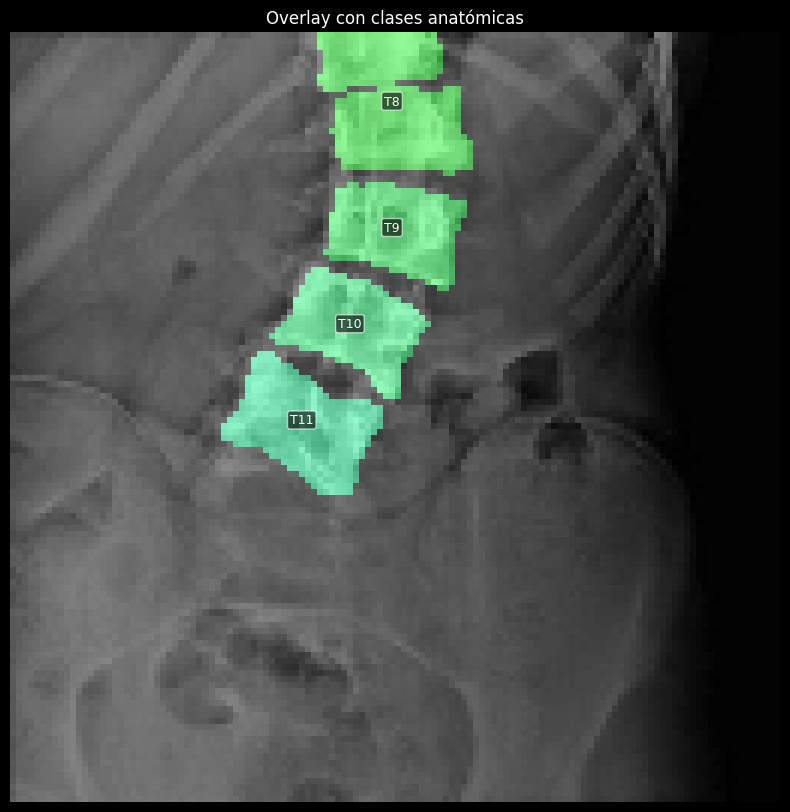

In [22]:
image, mask = train_dataset.__getitem__(10)
print(image[0].shape)
image = image[0].permute(1, 2, 0).cpu().numpy()
mask = mask[0].squeeze().cpu().numpy()
show_overlay_with_labels(image, mask, dic_labels)

torch.Size([8, 3, 128, 128])


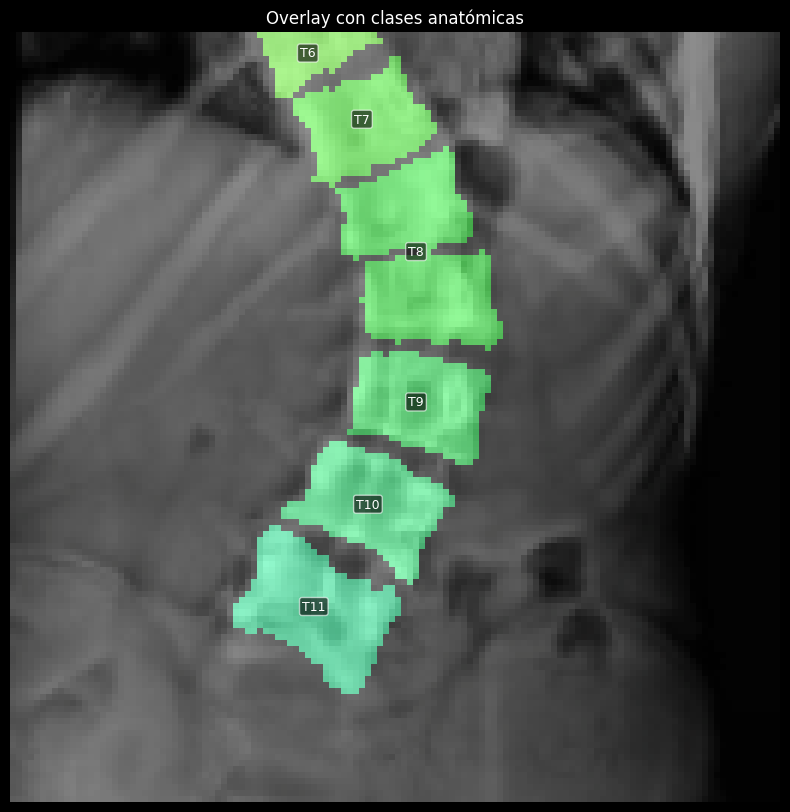

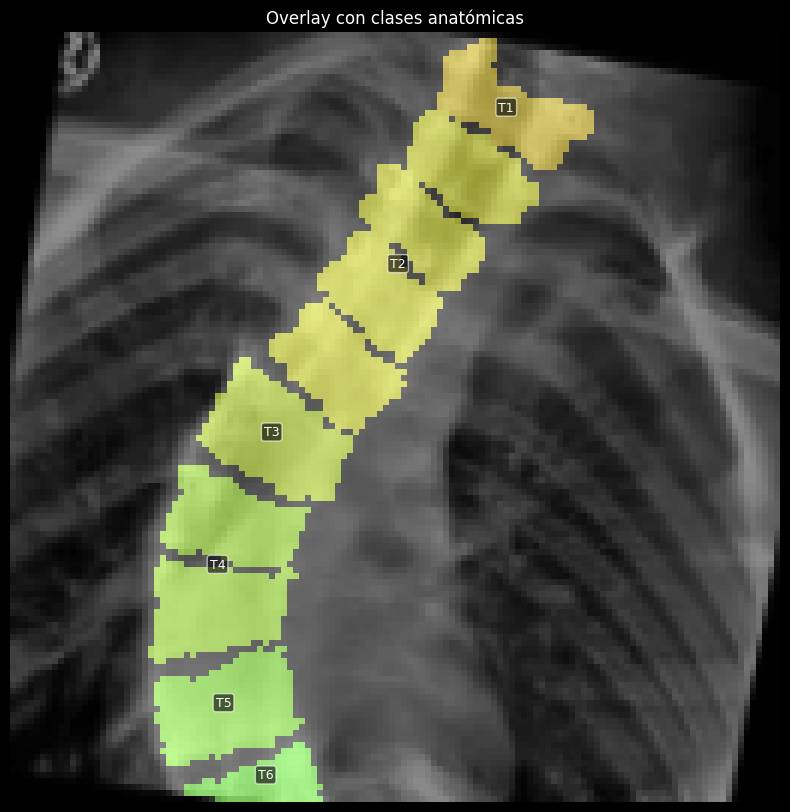

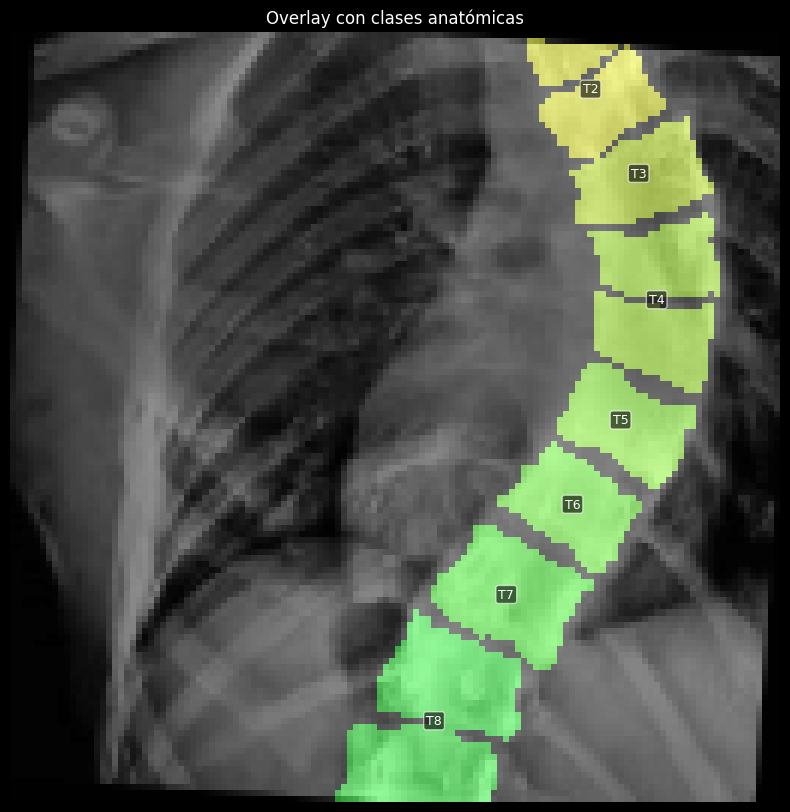

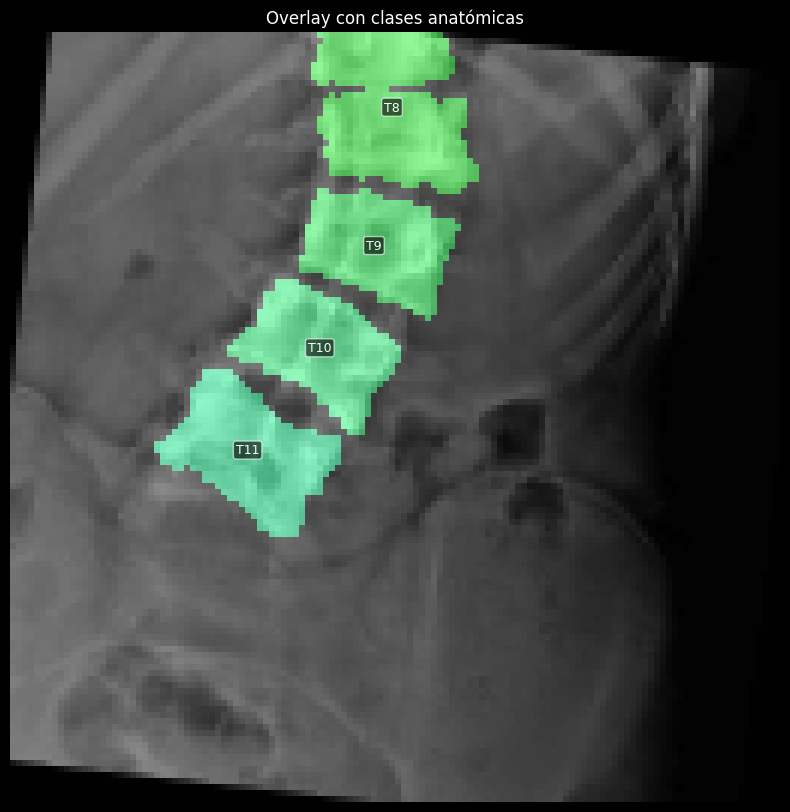

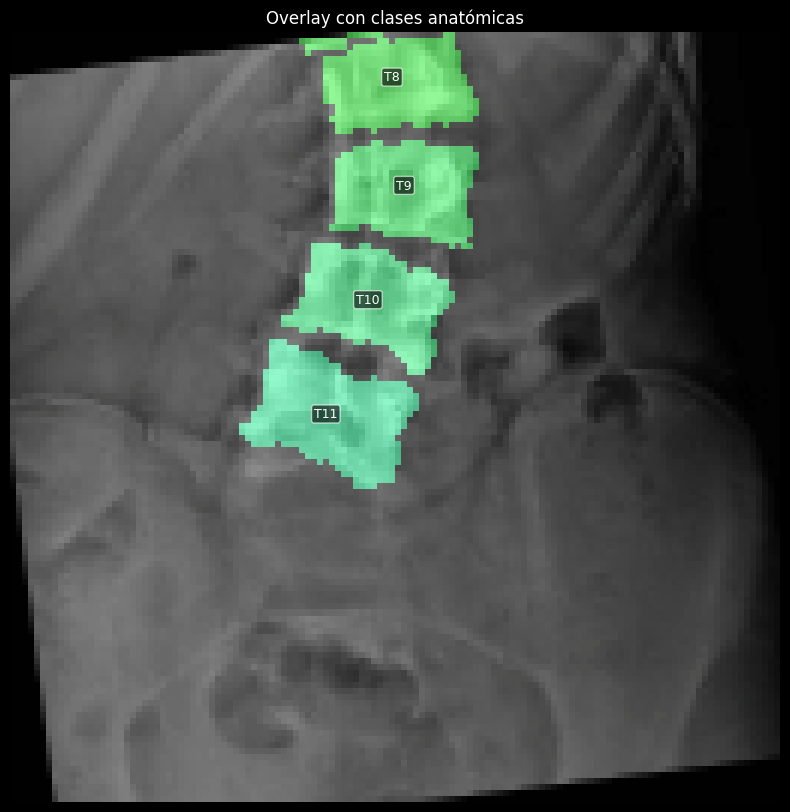

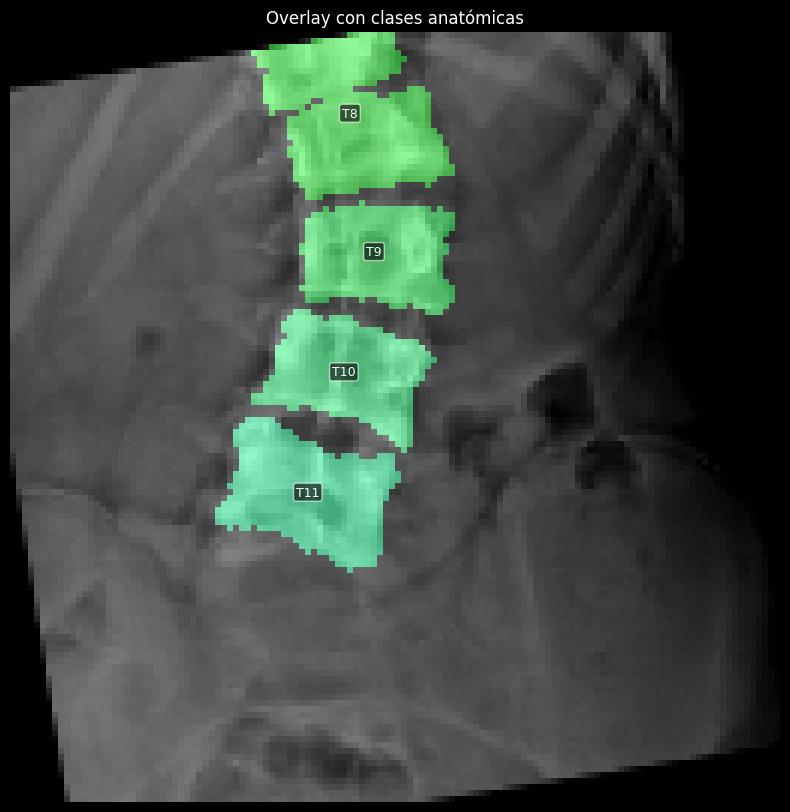

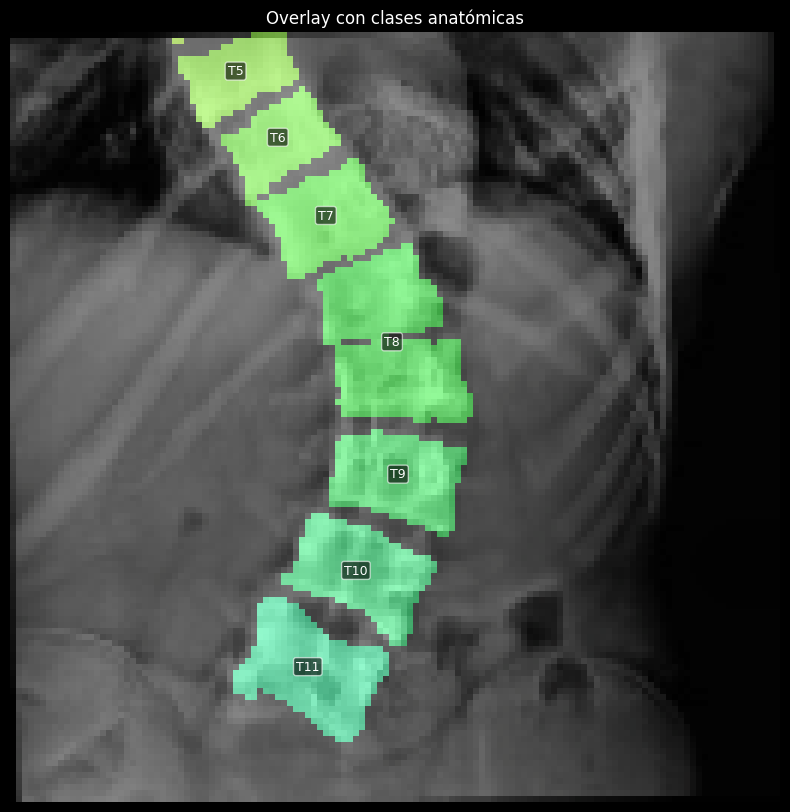

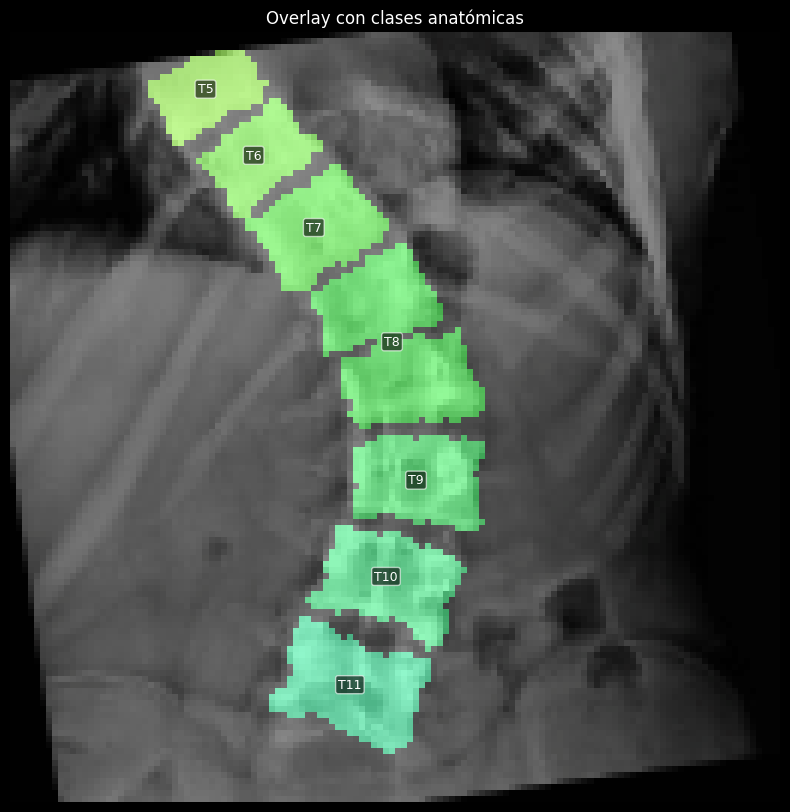

In [23]:
images, masks = train_dataset.__getitem__(10)
print(images.shape)
for image, mask in zip(images, masks):
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze().cpu().numpy()
    show_overlay_with_labels(image, mask, dic_labels)

In [24]:
if MODEL_NAME == 'Unet++':
    model = smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )
elif MODEL_NAME == 'Segformer':
    model = smp.Segformer(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        # aux_params={'classes':NUM_CLASSES, 'dropout':0.2}
    )
if MODEL_NAME == 'U-net':
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )

if MODEL_NAME == 'DeepLabV3+':
        model = smp.DeepLabV3Plus(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=IN_CHANNELS,
            classes=NUM_CLASSES,
            # decoder_attention_type = DECODER_ATTENTION,
            # pooling='max',
            # dropout = 0.5
        )

if DROPOUT is not None:
        model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT), model.segmentation_head)
model = model.to(device)

# Definir la función de pérdida y el optimizador
# Usamos BCEWithLogitsLoss porque el modelo no tiene una capa sigmoide final por defecto
# criterion = nn.BCEWithLogitsLoss()

if LOSS == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()

elif LOSS == 'DiceLoss':
    criterion =  DiceLoss()

elif LOSS == 'CombinedLoss':
    criterion = CombinedLoss()

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

if not TRAIN_ENCODER:
    for param in model.encoder.parameters():
        param.requires_grad = False


# Definir el scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',    # 'min' porque quieres que la pérdida disminuya
    factor=0.1,    # Reduce el LR al 10% (multiplica por 0.1)
    patience=PATIENCE,    # Espera 5 épocas sin mejora antes de reducir
    threshold=1e-4, # Cambio mínimo para considerar que hay mejora
)

In [25]:
# with mlflow.start_run(experiment_id=experiment.experiment_id):

train_losses = np.zeros(NUM_EPOCHS)
val_losses = np.zeros(NUM_EPOCHS)
val_dice = np.zeros(NUM_EPOCHS)
best_epoch = 0
best_metric = 0
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        B, N, C, H, W = images.shape
        images = images.view(B*N, C, H, W)
        masks = masks.view(B * N, H, W).to(device)

        images, masks = images.float().to(device), masks.long().to(device) # <--- Asegurar .long()


        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)

        # pred_mask = torch.argmax(outputs, dim=1)
        loss = criterion(outputs, masks)
        # loss = criterion(pred_mask, masks)

        # Backward pass y optimización
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validación simple
    model.eval()
    val_loss = 0.0
    dice_score_val = torch.empty((0,NUM_CLASSES))
    IoU_score_val = torch.empty((0,NUM_CLASSES))
    with torch.no_grad():
        for images, masks in val_loader:
            B, N, C, H, W = images.shape
            images = images.view(B*N, C, H, W)
            masks = masks.view(B * N, H, W).to(device)
            images, masks = images.float().to(device), masks.long().to(device)
            outputs = model(images)

            loss = criterion(outputs, masks)
            # loss = criterion(pred_mask, masks)
            val_loss += loss.item()

            pred_mask = torch.argmax(outputs, dim=1)

            dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
            dice_score_val = torch.cat((dice_score_val, dice), dim=0)
            IoU_score_val = torch.cat((IoU_score_val, IoU), dim=0)
        dice_score_val = torch.mean(dice_score_val)
        IoU_score_val = torch.mean(IoU_score_val)

    if dice_score_val > best_metric and epoch > 15:
        best_metric = dice_score_val
        torch.save(model.state_dict(), os.path.join('modelos',MODEL_NAME+'.pth'))
        best_epoch = epoch + 1

    train_losses[epoch] = train_loss / len(train_loader)
    val_losses[epoch] = val_loss / len(val_loader)

    scheduler.step(val_loss/len(val_loader))
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val DICE Score: {dice_score_val:.4f} | Val IoU Score: {IoU_score_val:.4f}")

print('Best Epoch: ', best_epoch, ' Best metric: ', best_metric)

    # mlflow.log_params({'best_epoch': best_epoch, 'EPOCHS': NUM_EPOCHS, 'SEED': SEED, 'BATCH_SIZE': BATCH_SIZE, 'PATIENCE': PATIENCE, 'LR': LR, 'WD': WD, 'IMG_SIZE': IMG_SIZE, 'IN_CHANNELS': IN_CHANNELS, 'TRAIN_ENCODER': TRAIN_ENCODER, 'CENTER_IMAGES': CENTER_IMAGES, 'CLAHE': CLAHE, 'PERSPECTIVE': PERSPECTIVE ,'LOSS': LOSS, 'ENCODER_NAME': ENCODER_NAME, 'DECODER_ATTENTION': DECODER_ATTENTION, 'DROPOUT': DROPOUT})
    #
    # mlflow.log_metric(f"val_mean_dice_score", dice_score_val)
    # mlflow.log_metric(f"best_val_dice_score", dice_score_val)
    # mlflow.pytorch.log_model(model, name=MODEL_NAME)
    #
    # for step, value in enumerate(train_losses):
    #     mlflow.log_metric('train_hist', value, step=step)
    # for step, value in enumerate(val_losses):
    #     mlflow.log_metric('val_hist', value, step=step)


Epoch 1/50 | Train Loss: 2.2056 | Val Loss: 1.7776 | Val DICE Score: 0.6137 | Val IoU Score: 0.6088
Epoch 2/50 | Train Loss: 1.5106 | Val Loss: 1.6367 | Val DICE Score: 0.5566 | Val IoU Score: 0.5502
Epoch 3/50 | Train Loss: 1.4572 | Val Loss: 1.5144 | Val DICE Score: 0.5592 | Val IoU Score: 0.5516
Epoch 4/50 | Train Loss: 1.4539 | Val Loss: 1.5577 | Val DICE Score: 0.5486 | Val IoU Score: 0.5435
Epoch 5/50 | Train Loss: 1.4079 | Val Loss: 1.4923 | Val DICE Score: 0.5303 | Val IoU Score: 0.5217
Epoch 6/50 | Train Loss: 1.3751 | Val Loss: 1.5063 | Val DICE Score: 0.5368 | Val IoU Score: 0.5280
Epoch 7/50 | Train Loss: 1.3455 | Val Loss: 1.4998 | Val DICE Score: 0.5422 | Val IoU Score: 0.5320
Epoch 8/50 | Train Loss: 1.3050 | Val Loss: 1.4755 | Val DICE Score: 0.5257 | Val IoU Score: 0.5135
Epoch 9/50 | Train Loss: 1.2840 | Val Loss: 1.4659 | Val DICE Score: 0.5490 | Val IoU Score: 0.5350
Epoch 10/50 | Train Loss: 1.2699 | Val Loss: 1.4088 | Val DICE Score: 0.5463 | Val IoU Score: 0.5290

In [26]:
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

UnetPlusPlus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding

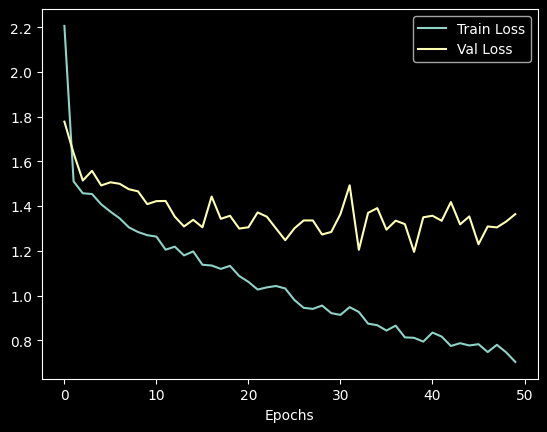

In [27]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel('Epochs')
plt.legend()

Resolución imagen original: (2779, 1160, 3)


Procesando filas:   0%|          | 0/6 [00:00<?, ?it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03158700180053714..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.029056316375732416..1.0000000236034394].
Procesando filas:  17%|█▋        | 1/6 [00:00<00:00,  5.31it/s]

0 0
0 0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06694310796260833..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05765931582450867..1.0000000236034394].
Procesando filas:  33%|███▎      | 2/6 [00:00<00:00,  5.57it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07853405761718751..1.0000000236034394].


0 0
0 0


...

0 0
0 0


Procesando filas:  67%|██████▋   | 4/6 [00:00<00:00,  5.25it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023529407501220734..1.0000000236034394].


0 0
0 0
0 0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08621322786808017..1.0000000236034394].
Procesando filas:  83%|████████▎ | 5/6 [00:00<00:00,  5.39it/s]C:\Users\juanm\AppData\Local\Temp\ipykernel_27784\4154968894.py:87: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023529407501220734..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.164797794342041..1.0000000236034394].
Procesando filas: 100%|██████████| 6/6 [00:01<00:00, 

0 0
0 0
0 0
Forma de máscara final: (2779, 1160) Forma imagen original: (2779, 1160, 3)


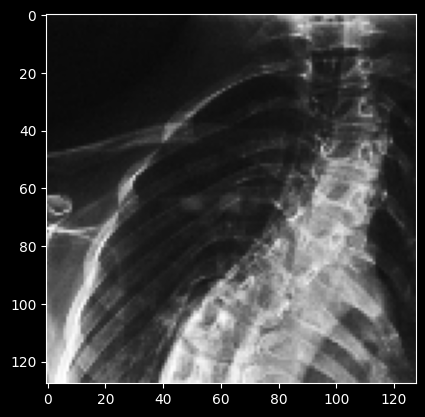

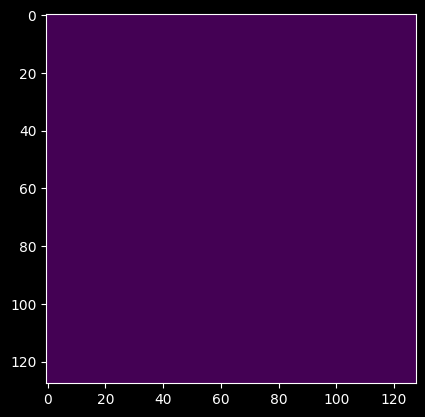

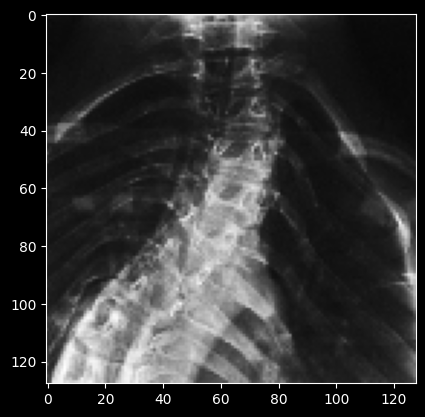

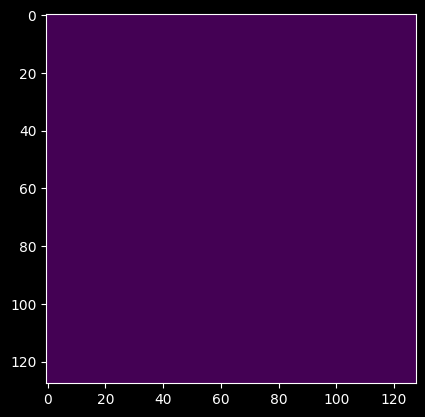

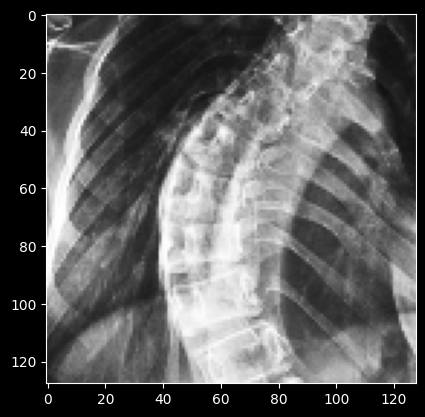

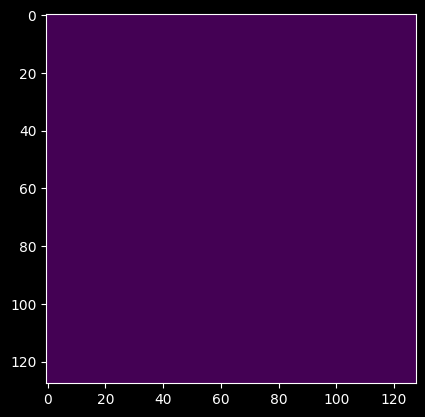

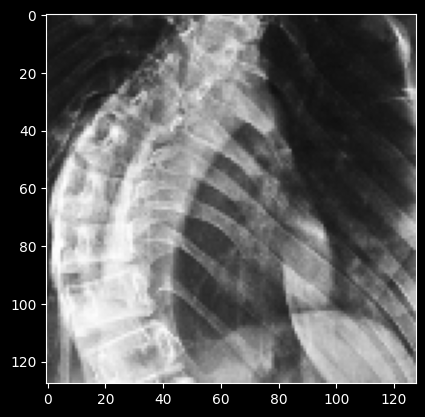

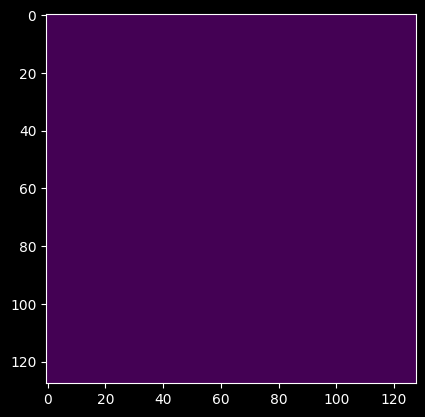

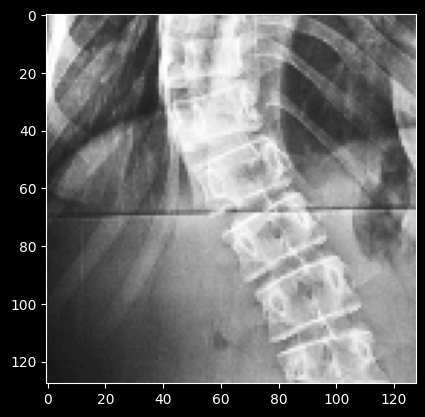

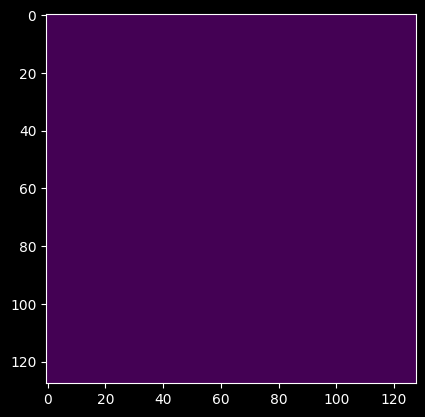

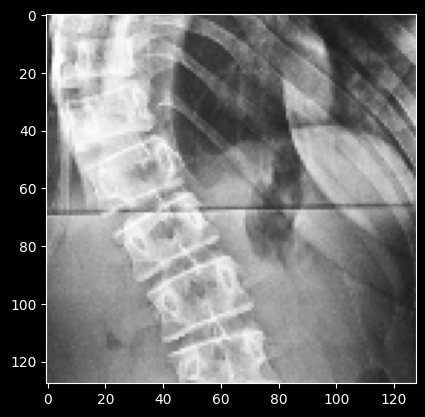

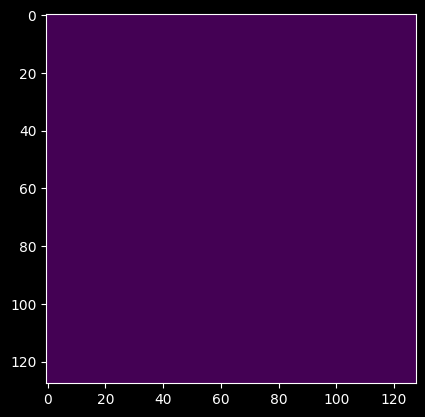

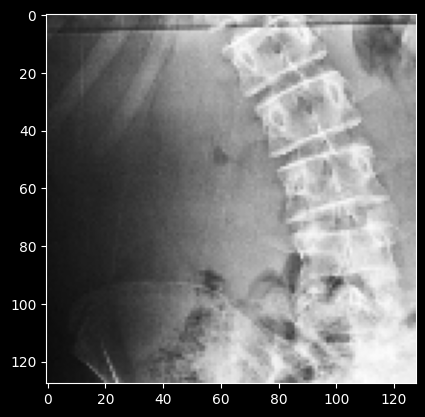

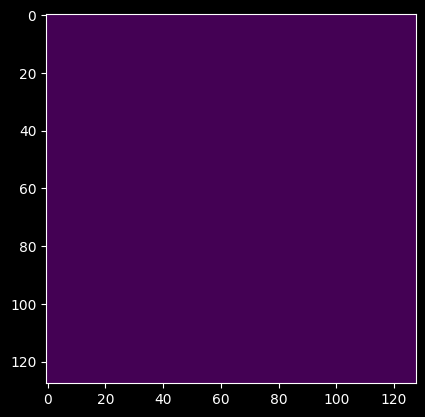

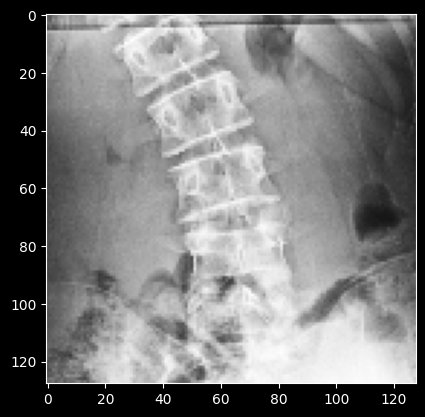

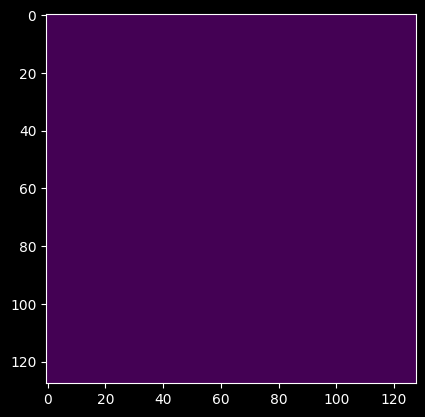

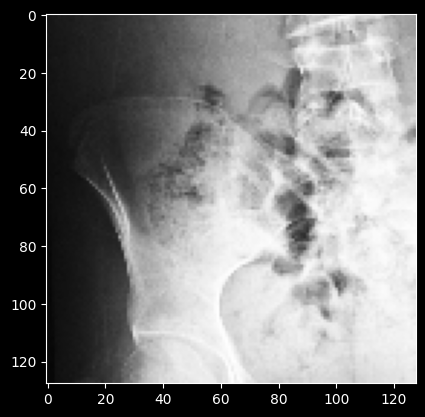

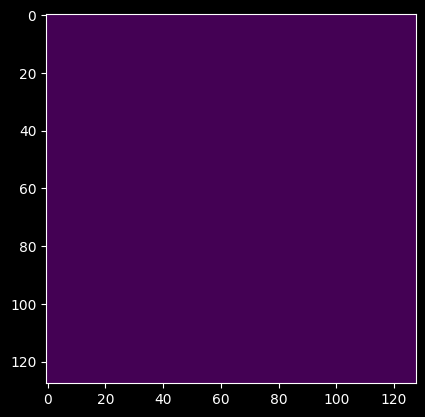

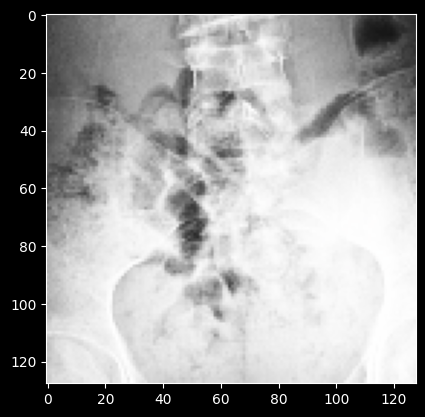

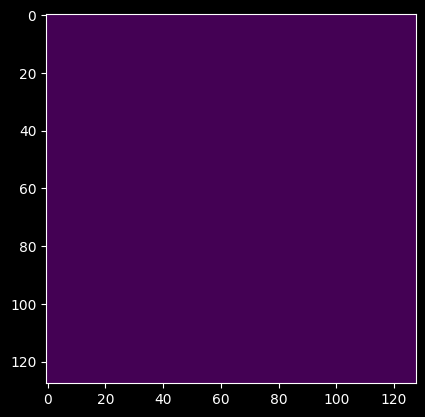

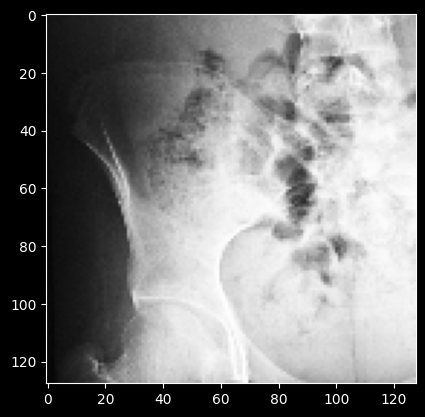

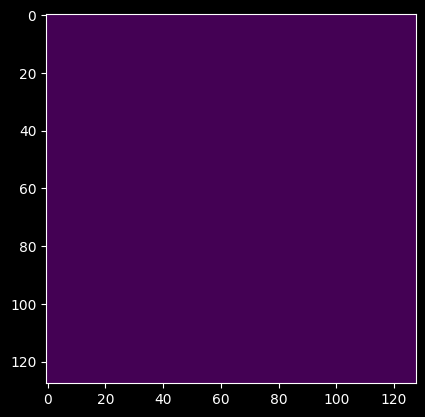

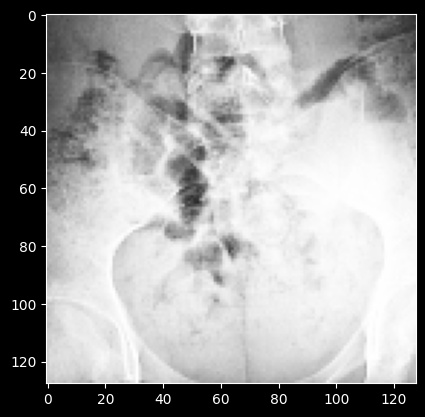

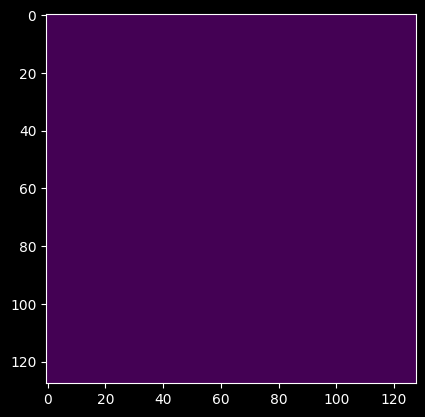

In [89]:
import torch
import numpy as np
import torch.nn.functional as F
import cv2
from tqdm import tqdm

def create_gaussian_window(patch_size, sigma=1.0):
    """
    Crea una matriz de pesos 2D con una distribución Gaussiana.
    Da más peso al centro del parche y menos a los bordes.
    """
    tmp = np.zeros((patch_size, patch_size))
    # Crear un centro
    center = patch_size // 2

    # Generar grid
    x, y = np.ogrid[:patch_size, :patch_size]

    # Formula gaussiana simplificada
    d2 = (x - center)**2 + (y - center)**2
    # El valor 2*sigma^2 controla qué tan rápido cae el peso hacia los bordes
    std_squared = 2 * (sigma * patch_size / 2)**2
    window = np.exp(-d2 / std_squared)

    # Normalizar para que el valor máximo sea 1.0 (opcional, ayuda a la estabilidad)
    window = window / np.max(window)

    # Convertir a tensor de PyTorch para usar en GPU
    return torch.from_numpy(window).float()

def patch_based_inference(model, image, patch_size, stride, num_classes, device):
    """
    Realiza inferencia en una imagen grande usando ventanas deslizantes con solape y suavizado.

    image: Tensor [C, H_large, W_large] pre-procesado (normalizado).
    """
    model.eval()
    H_large, W_large, _ = image.shape

    # 1. Crear tensores vacíos en la GPU para acumular las predicciones y los pesos
    # Forma: [Num_Clases, H, W]
    # Usamos floats para acumular probabilidades
    accumulated_predictions = torch.zeros((num_classes, H_large, W_large)).to(device)
    accumulated_weights = torch.zeros((H_large, W_large)).to(device)

    # 2. Crear la ventana Gaussiana de suavizado
    gaussian_window = create_gaussian_window(PATCH_SIZE, sigma=1.0).to(device)

    # 3. Bucle de Ventana Deslizante (Sliding Window)
    # Calculamos cuántos pasos dar en y y x
    y_steps = range(0, H_large - patch_size + 1, stride)
    x_steps = range(0, W_large - patch_size + 1, stride)

    # Asegurar que cubrimos el borde final si el stride no encaja perfecto
    # (Añadimos el último parche posible si no termina exactamente en el borde)

    if y_steps[-1] + patch_size < H_large:
        y_steps = list(y_steps) + [H_large - patch_size]
    if x_steps[-1] + patch_size < W_large:
        x_steps = list(x_steps) + [W_large - patch_size]

    # print(len(x_steps), W_large, patch_size,stride)

    with torch.no_grad():
        # Usamos tqdm para ver progreso ya que esto tarda
        image = (image / 255.0 - MEAN) / STD
        for y in tqdm(y_steps, desc="Procesando filas"):
            for x in x_steps:
                # Extaer el parche de la imagen grande

                # print(image_norm.shape)
                # HWC a CHW y convertir a Tensor
                patch = image[y:y+patch_size, x:x+patch_size, :]
                patch = cv2.resize(patch, (PATCH_SIZE, PATCH_SIZE))

                transform = torchvision.transforms.ToTensor()
                patch = transform(patch).float()
                # print(patch.shape)

                # Añadir dimensión de batch -> [1, C, H_patch, W_patch]
                patch_batch = patch.unsqueeze(0).to(device)

                # Inferencia del modelo (Logits) -> [1, 18, H_patch, W_patch]
                logits = model(patch_batch)
                pred_mask_patch = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

                plt.figure()
                plt.imshow((patch.permute(1, 2, 0).cpu().numpy())*STD + MEAN)
                plt.figure()
                plt.imshow(pred_mask_patch)
                print(np.max(pred_mask_patch), np.min(pred_mask_patch))

                # Convertir logits a probabilidades (Softmax)
                # Esto es crucial para la fusión ponderada
                probs = F.softmax(logits, dim=1).squeeze(0) # -> [18, H_patch, W_patch]

                # 4. Aplicar Fusión Ponderada en la GPU
                # Multiplicar las probabilidades de cada clase por el peso Gaussiano
                weighted_probs = probs * gaussian_window.unsqueeze(0) # Broadcatsing de canales

                # Acumular en la imagen grande
                accumulated_predictions[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE] += weighted_probs

                # Acumular los pesos aplicados en esa zona para luego normalizar
                accumulated_weights[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += gaussian_window

    # 5. Normalización Final
    # Dividir las probabilidades acumuladas por la suma de pesos en cada píxel
    # Usamos una pequeña constante (1e-5) para evitar división por cero en bordes extremos
    final_segmentation_probs = accumulated_predictions / (accumulated_weights.unsqueeze(0) + 1e-5)

    return final_segmentation_probs



img_path = test_img[0]
image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)

x, y, _ = image.shape
patch_size = np.round(np.sqrt(0.25*x*y)).astype(int)
stride = np.round(patch_size/2).astype(int)

# 4. Parímetros de Inferencia
# STRIDE define el solapamiento.
# Si Stride == Patch_Size -> No hay solape (Malos bordes)
# Si Stride == Patch_Size // 2 -> 50% solape (Buen balance velocidad/calidad)

print(f"Resolución imagen original: {image.shape}")

# 5. Ejecutar Inferencia Patch-Based
probs_map = patch_based_inference(
    model,
    image,
    patch_size,
    stride,
    NUM_CLASSES,
    device
)

# 6. Post-procesamiento
# El resultado es [18, H, W] con probabilidades.
# Tomamos el ARGMAX para obtener la clase final por píxel
final_mask = torch.argmax(probs_map, dim=0).cpu().numpy() # -> [H, W] con valores 0-17

print(f"Forma de máscara final: {final_mask.shape}", f"Forma imagen original: {image.shape}")

# 7. Guardar o visualizar
# (Necesitarás un mapeo de color para visualizar 18 clases)
# cv2.imwrite("segmentacion_final.png", final_mask)

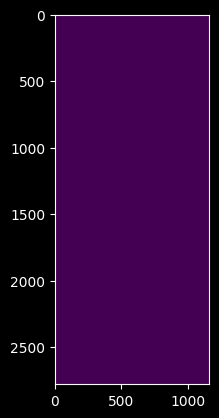

In [82]:
plt.imshow(final_mask)

In [29]:
print(create_gaussian_window(5))

NameError: name 'create_gaussian_window' is not defined

In [ ]:
def gkern(l=5, sig=1.):
    """\
    creates gaussian kernel with side length `l` and a sigma of `sig`
    """
    ax = np.linspace(-(l - 1) / 2., (l - 1) / 2., l)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sig))
    kernel = np.outer(gauss, gauss)
    return kernel

In [ ]:
gkern(l=5, sig=1.)

In [ ]:
final_mask

In [ ]:
dice_score_test = np.zeros(NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            image, mask = image.float().unsqueeze(0).to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu()
            dice, IoU = compute_metrics(pred_mask.cpu().numpy(), mask.to(torch.long).cpu().numpy(), average=False)
            dice_score_test += dice

dice_score_test = dice_score_test/len(test_dataset)

for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [ ]:
x = range(len(dice_score_test))
f, ax = plt.subplots()
ax.bar(x, dice_score_test)
ax.set_xticks(x)
labels = [dic_labels['mascara_multiclase_id_png'][i] for i  in dic_labels['mascara_multiclase_id_png']]
ax.set_xticklabels(labels)
ax.figure.set_size_inches(15, 5)
ax.set_xlabel('Label')
ax.set_ylabel('mean DICE score')

In [ ]:
dice_score_test = torch.zeros(NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            image, mask = image.unsqueeze(0).float().to(device), mask.unsqueeze(0).long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).cpu()
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), mask.to(torch.long).cpu(), average=False)
            dice_score_test += dice.squeeze(0)

dice_score_test = dice_score_test/len(test_dataset)
print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')


for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [ ]:
dice_score_test = torch.empty((0,18))
with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.float().to(device), masks.long().to(device)
            # print(images.shape, masks.shape)
            outputs = model(images)
            pred_mask = torch.argmax(outputs, dim=1)
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
            # print(dice.shape)
            dice_score_test = torch.cat((dice_score_test, dice), dim=0)

print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')
mean_dice_score = torch.mean(dice_score_test, dim=0).numpy()

for i,j in zip(dic_labels['mascara_multiclase_id_png'], mean_dice_score):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels(
    model,
    dataset,
    device,
    idx,
    patch_idx,
    label_dict,
    alpha=0.45,
    min_pixels=20
):
    model.eval()

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    print(dataset.__getpath__(idx))

    sample = dataset[idx]
    if sample is None:
        print(f"No se pudo cargar la muestra {idx}")
        return

    image_tensor, gt_mask = sample
    image_tensor = image_tensor[patch_idx]
    gt_mask = gt_mask[patch_idx]
    image_batch = image_tensor.float().unsqueeze(0).to(device)

    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)
    print(logits)
    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    # dice_score = DiceScore(num_classes=NUM_CLASSES, average="none", input_format='index')
    # dice_score_mean = DiceScore(num_classes=NUM_CLASSES, average="macro", input_format='index')
    # dice_score_mean = dice_score_mean(pred_mask, gt_mask.to(torch.long).cpu())
    # sample_dice = dice_score(pred_mask, gt_mask.to(torch.long).cpu())

    pred_mask = pred_mask.numpy()
    gt_mask = gt_mask.cpu().numpy()

    sample_dice, sample_IoU = compute_metrics(pred_mask, gt_mask, average=False)
    dice_score_mean, IoU_score_mean = compute_metrics(pred_mask, gt_mask)

    image = image_tensor.cpu().numpy()
    if image.shape[0] == 1:
        image = image.squeeze(0)
        image_cmap = "gray"
    else:
        image = np.transpose(image, (1, 2, 0))
        image_cmap = None

    # image = np.clip(image, 0, 1)

    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title("Predicción con etiquetas")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    gt_classes = np.unique(gt_mask)
    pred_classes = np.unique(pred_mask)
    # print(f'Dice Score promedio: {dice_score_mean.numpy():.4f}')
    print(f'Dice Score promedio: {dice_score_mean:.4f}')
    print('Dice Score por clase: ')
    for i,j in zip(dic_labels['mascara_multiclase_id_png'], sample_dice):
        # print(dic_labels['mascara_multiclase_id_png'][i],j.numpy())
        print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')
    # print(f"DICE Score: {sample_dice:.4f}")

    # print("\nClases presentes en Ground Truth:")
    # for c in gt_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")
    #
    # print("\nClases presentes en Predicción:")
    # for c in pred_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")

0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[ 3.7285,  4.9492,  4.6875,  ...,  6.2109,  6.2852,  4.4219],
          [ 4.9922,  6.3320,  5.7773,  ...,  7.1680,  7.5391,  5.5391],
          [ 5.3516,  6.7773,  5.7773,  ...,  6.6094,  7.1602,  5.2969],
          ...,
          [ 5.5352,  7.4766,  7.1836,  ...,  7.0117,  7.5938,  5.4375],
          [ 5.6914,  7.6172,  7.3867,  ...,  7.5000,  7.7383,  5.3281],
          [ 3.4727,  5.1523,  5.0625,  ...,  5.2344,  5.2539,  3.8184]],

         [[-3.6348, -5.8828, -6.3398,  ..., -5.8203, -6.5469, -4.8789],
          [-5.2539, -8.1250, -8.6016,  ..., -7.6719, -8.5625, -6.5078],
          [-5.2852, -7.7734, -7.7930,  ..., -6.7031, -7.6406, -6.0234],
          ...,
          [-5.1328, -7.0625, -6.9102,  ..., -7.0703, -7.8086, -5.8672],
          [-5.2305, -7.4805, -7.5352,  ..., -7.8047, -8.1719, -6.0430],
          [-3.4473, -4.9336, -4.9922,  ..., -5.2891, -5.3711, -3.8672]],

         

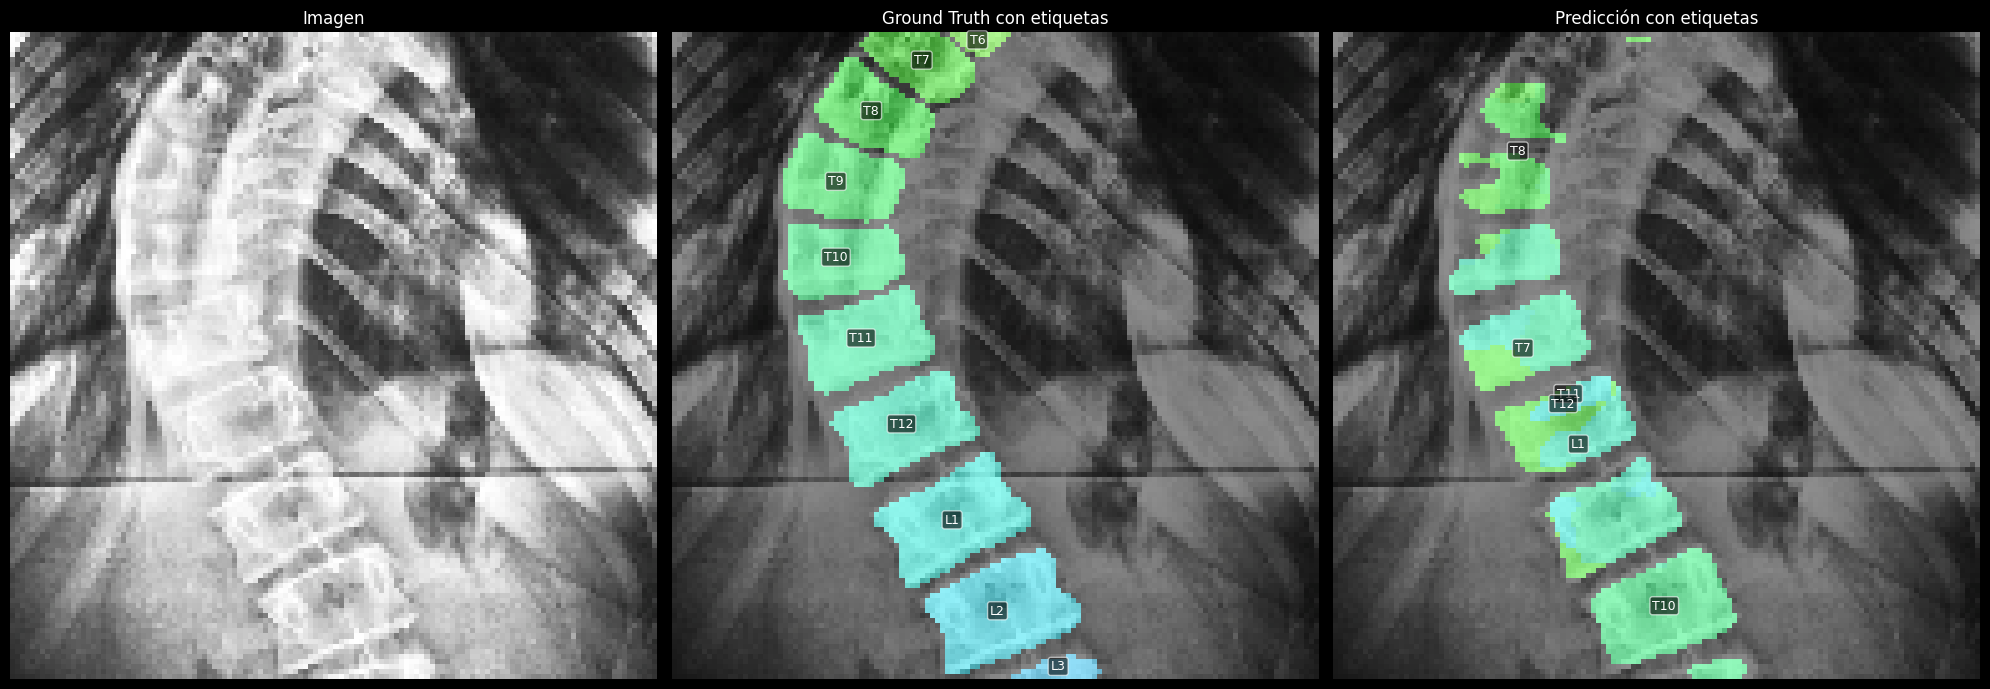

Dice Score promedio: 0.5199
Dice Score por clase: 
background 0.9666
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 0.0000
T8 0.3856
T9 0.0637
T10 0.0183
T11 0.3351
T12 0.4025
L1 0.1863
L2 0.0000
L3 0.0000
L4 1.0000
L5 1.0000
0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[  4.3125,   5.9844,   5.8516,  ...,   5.9453,   6.0195,   4.2227],
          [  5.6211,   7.4414,   7.0625,  ...,   7.1953,   7.4492,   5.3320],
          [  5.4844,   7.2812,   6.6836,  ...,   7.0781,   7.3945,   5.3555],
          ...,
          [  4.4883,   5.8320,   5.6016,  ...,   5.0547,   5.4766,   4.0742],
          [  4.8633,   6.3984,   6.2188,  ...,   5.6484,   5.8516,   4.1680],
          [  3.2363,   4.8398,   4.7773,  ...,   4.2070,   4.3672,   3.4277]],

         [[ -3.5312,  -5.6562,  -6.2070,  ...,  -5.2852,  -5.8906,  -4.4336],
          [ -5.3281,  -8.0312,  -8.5938,  ...,  -7.3633,  -8.0859,  -6.0703],
          [ -5.5312,  -8

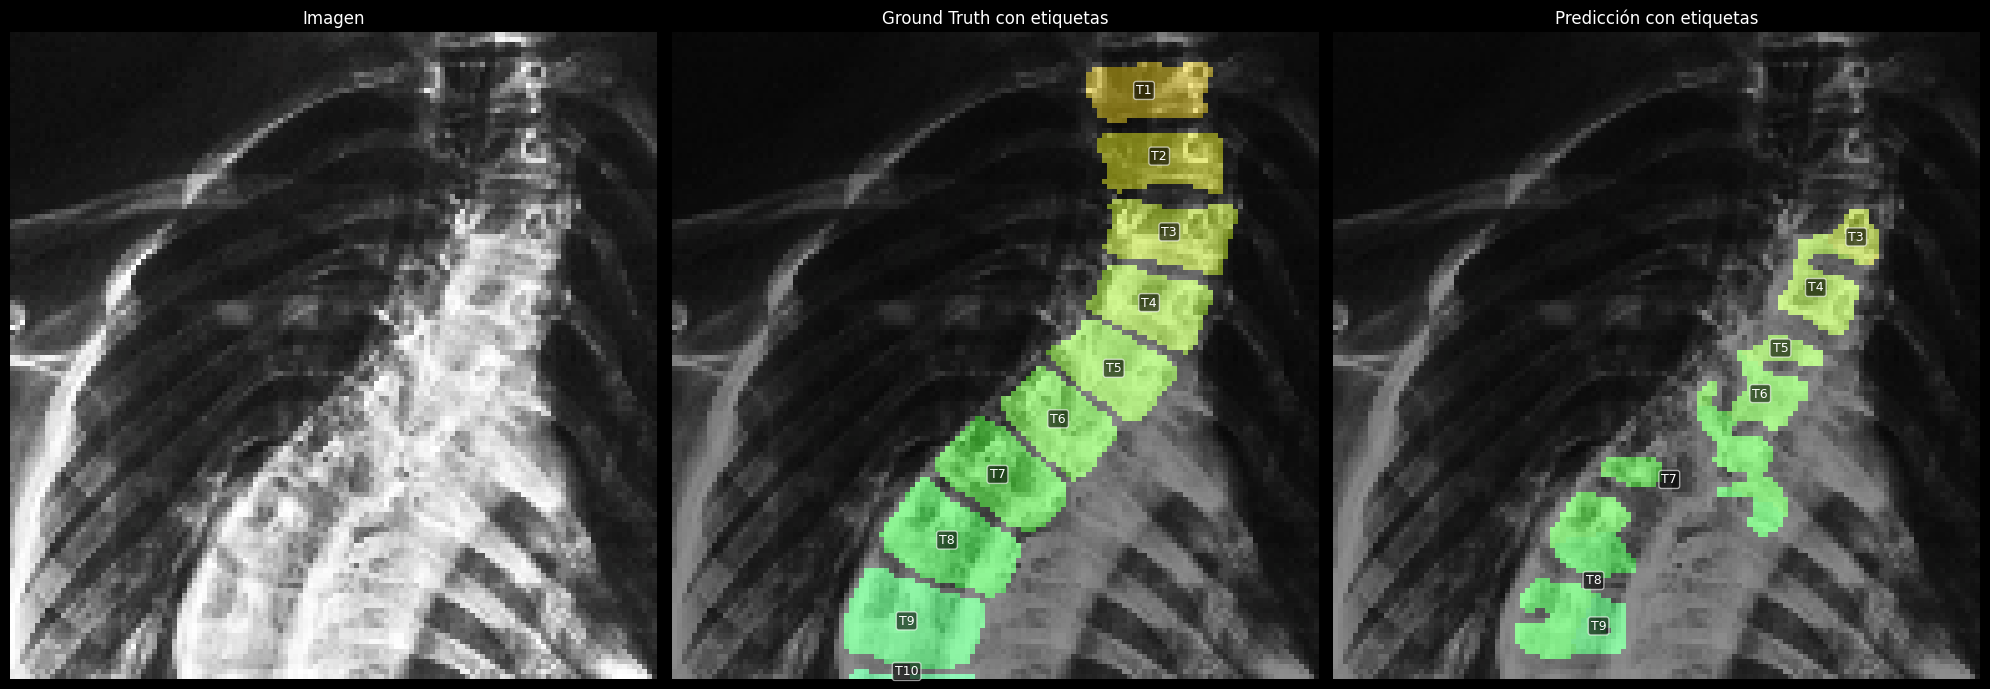

Dice Score promedio: 0.5736
Dice Score por clase: 
background 0.9343
T1 0.0000
T2 0.0000
T3 0.4055
T4 0.6013
T5 0.3314
T6 0.2081
T7 0.1810
T8 0.2902
T9 0.3725
T10 0.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[  3.7070,   4.8203,   4.4766,  ...,   5.7656,   6.0781,   4.2773],
          [  4.7695,   6.0938,   5.7070,  ...,   6.7422,   7.2109,   5.4844],
          [  4.8633,   6.1836,   5.5508,  ...,   6.3984,   6.8828,   5.1914],
          ...,
          [  5.8398,   7.7188,   7.3086,  ...,   6.3711,   6.5430,   4.6992],
          [  5.9531,   7.8984,   7.5742,  ...,   6.7891,   6.7422,   4.6953],
          [  3.6406,   5.3906,   5.2266,  ...,   5.0234,   4.8555,   3.6309]],

         [[ -4.3203,  -7.3711,  -8.4141,  ...,  -5.9062,  -6.2617,  -4.6797],
          [ -6.3047, -10.5078, -11.8516,  ...,  -8.1484,  -8.4219,  -6.3008],
          [ -6.2812, -10

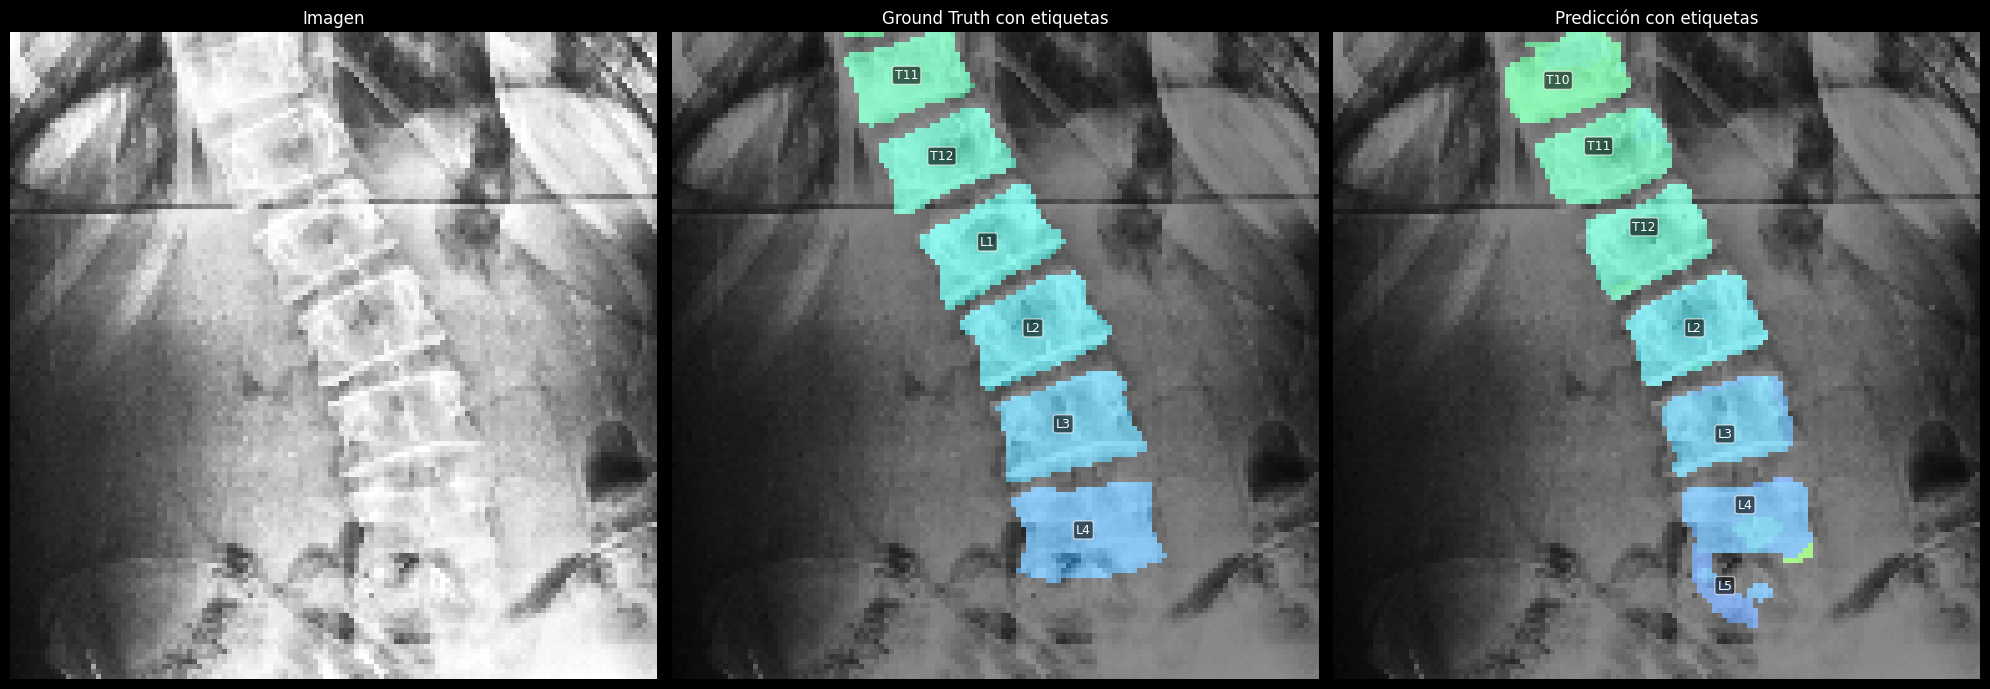

Dice Score promedio: 0.6472
Dice Score por clase: 
background 0.9816
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 0.0000
T11 0.1846
T12 0.0699
L1 0.0000
L2 0.9328
L3 0.8010
L4 0.6797
L5 0.0000
0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[  4.2070,   5.6328,   5.1445,  ...,   6.0078,   6.0430,   4.2344],
          [  5.5508,   7.0156,   6.1641,  ...,   7.2539,   7.4727,   5.3281],
          [  5.7812,   7.1758,   6.0234,  ...,   7.0469,   7.3477,   5.2812],
          ...,
          [  5.7383,   7.2227,   6.3711,  ...,   5.1406,   5.1602,   3.6914],
          [  5.8359,   7.3789,   6.8164,  ...,   5.7148,   5.6055,   3.9785],
          [  3.7324,   5.2891,   5.0547,  ...,   4.4297,   4.3086,   3.3438]],

         [[ -3.6582,  -5.7656,  -6.4414,  ...,  -5.5469,  -6.1836,  -4.6328],
          [ -5.3711,  -8.0781,  -8.8828,  ...,  -7.6055,  -8.3594,  -6.3047],
          [ -5.5039,  -7

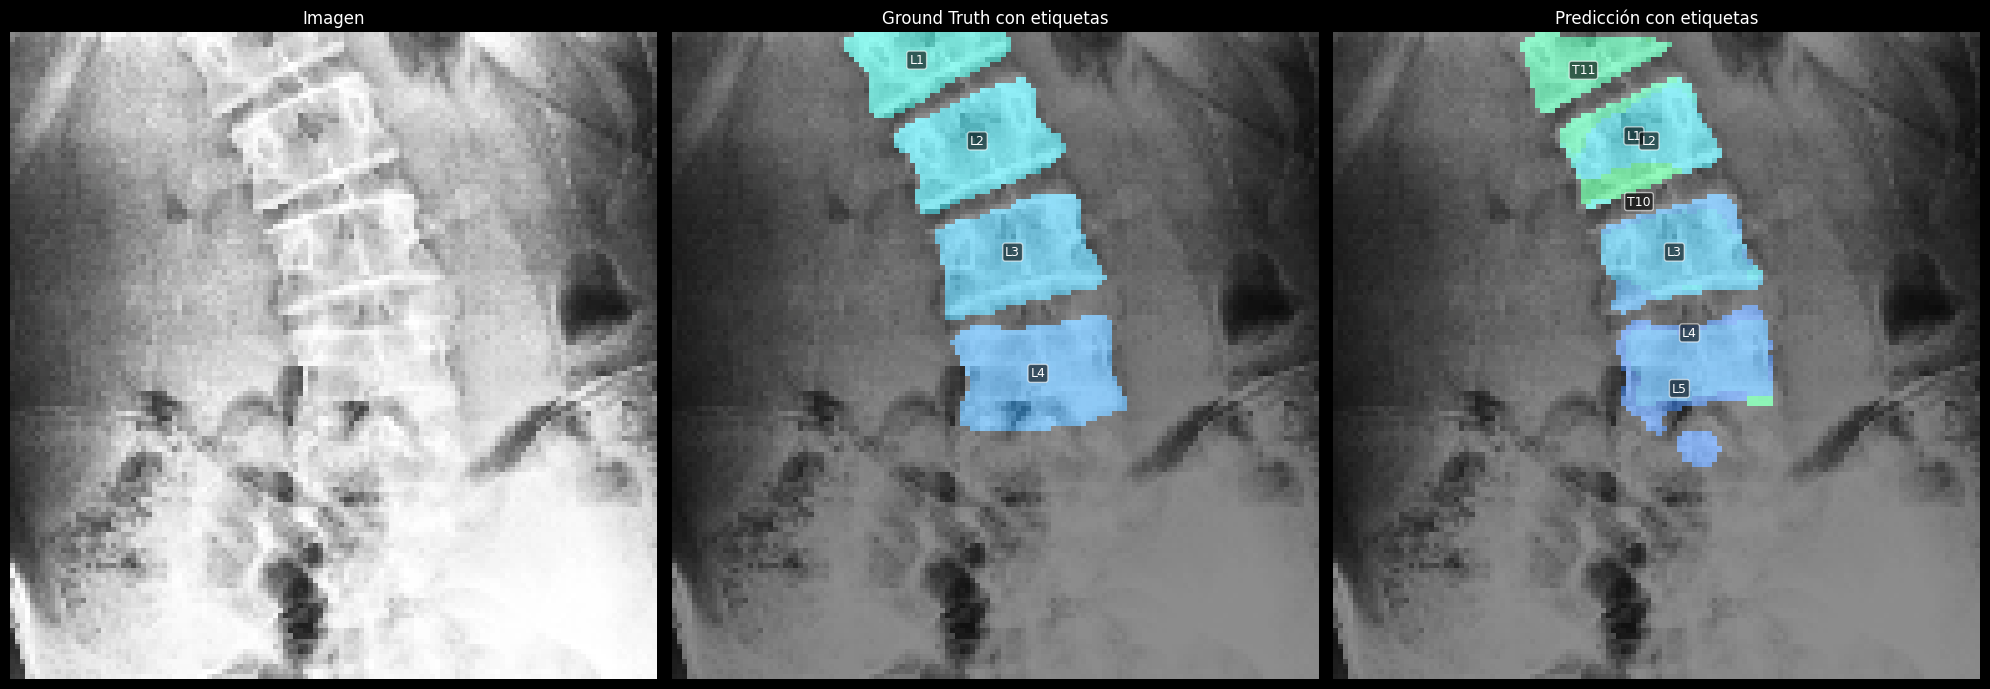

Dice Score promedio: 0.6789
Dice Score por clase: 
background 0.9853
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 0.7428
L3 0.8074
L4 0.6854
L5 0.0000
0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[  4.4219,   6.2461,   6.2227,  ...,   5.9102,   5.9414,   4.1641],
          [  5.6914,   7.7148,   7.5039,  ...,   7.1797,   7.3594,   5.2266],
          [  5.4648,   7.4648,   7.0469,  ...,   7.0977,   7.3438,   5.2852],
          ...,
          [  5.4453,   7.1992,   6.7109,  ...,   6.3789,   6.4023,   4.6172],
          [  5.5703,   7.2969,   6.7930,  ...,   6.9023,   6.7344,   4.7383],
          [  3.4102,   4.9648,   4.7188,  ...,   5.1250,   4.9805,   3.8008]],

         [[ -3.5254,  -5.3984,  -5.6992,  ...,  -5.1797,  -5.6875,  -4.2539],
          [ -5.3008,  -7.6641,  -7.8125,  ...,  -7.2539,  -7.8281,  -5.8359],
          [ -5.3086,  -7

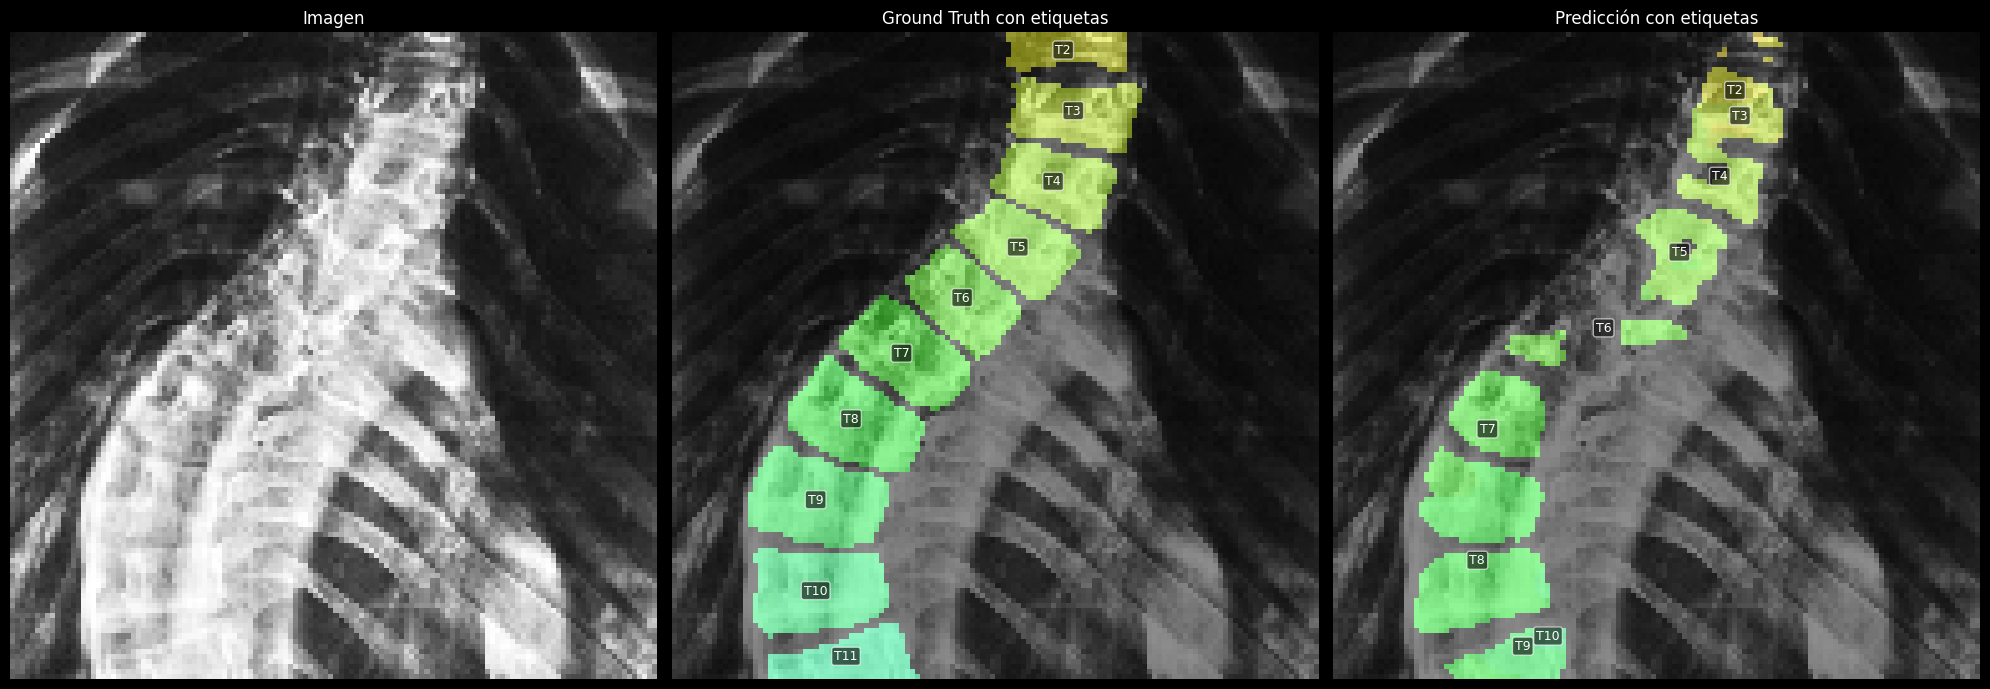

Dice Score promedio: 0.5084
Dice Score por clase: 
background 0.9503
T1 0.0000
T2 0.0781
T3 0.5226
T4 0.6488
T5 0.7093
T6 0.2417
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[ 4.2969,  6.1055,  6.0625,  ...,  6.1133,  6.2148,  4.3594],
          [ 5.4062,  7.4688,  7.2891,  ...,  7.3867,  7.7305,  5.5312],
          [ 5.1094,  7.2188,  6.9766,  ...,  7.0508,  7.6055,  5.5273],
          ...,
          [ 5.3477,  7.0117,  6.4727,  ...,  6.7539,  7.2969,  5.2266],
          [ 5.5508,  7.3711,  7.0039,  ...,  7.1914,  7.3984,  5.1523],
          [ 3.4512,  5.1094,  4.9805,  ...,  5.1250,  5.1094,  3.7109]],

         [[-3.4102, -5.1562, -5.3359,  ..., -5.4648, -6.0742, -4.5703],
          [-5.1211, -7.3438, -7.3750,  ..., -7.5430, -8.3125, -6.2930],
          [-5.0312, -6.8750, -6.6992,  ..., -7.0352, -7.8516, -6.0352],


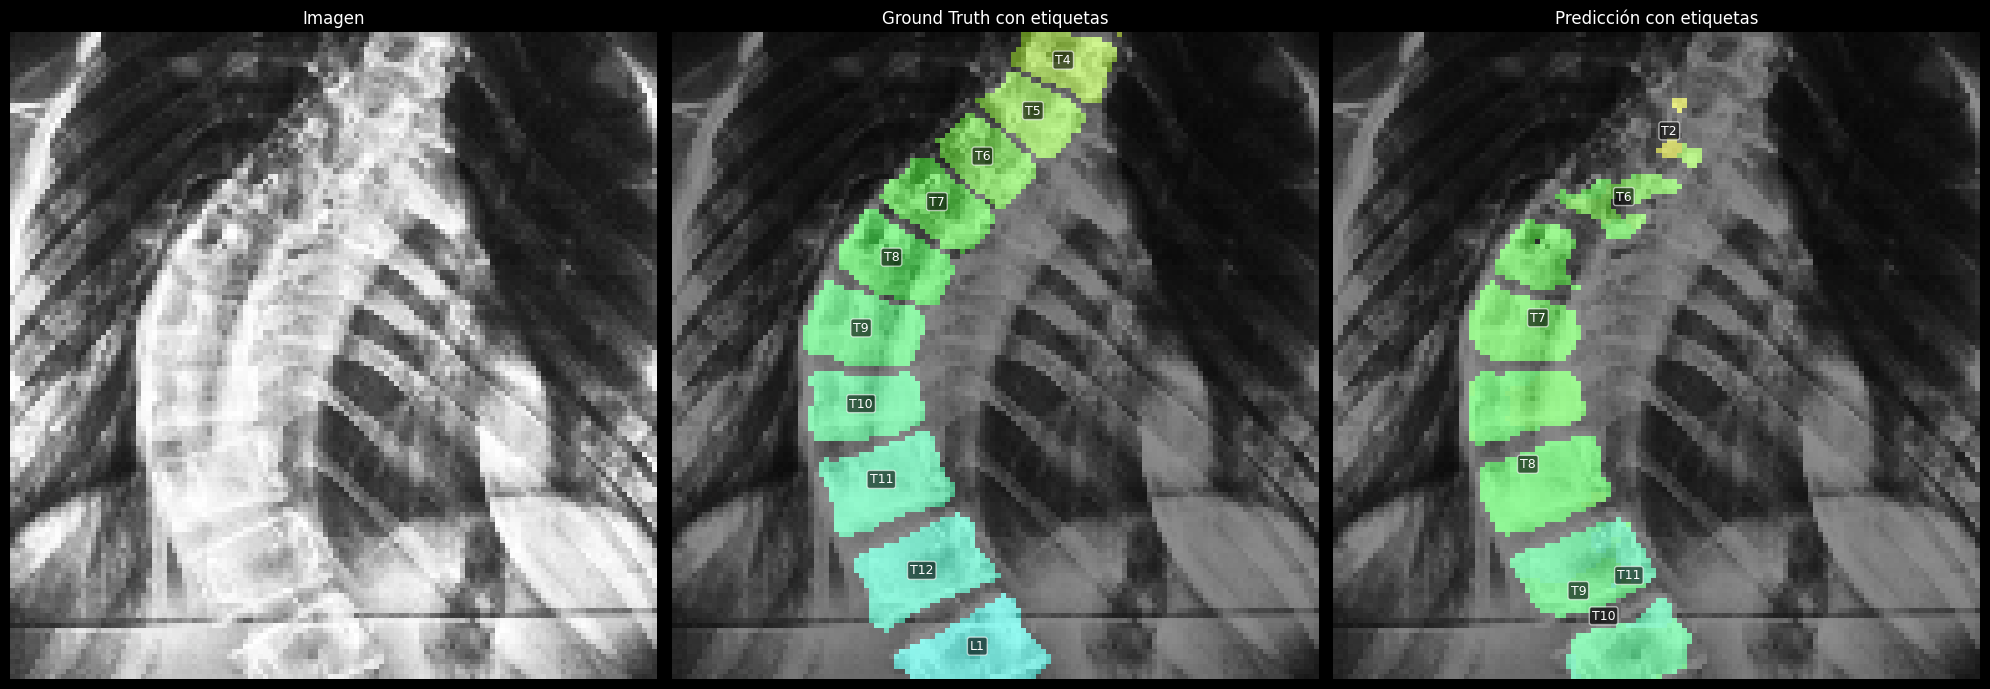

Dice Score promedio: 0.3502
Dice Score por clase: 
background 0.9617
T1 1.0000
T2 0.0000
T3 0.0000
T4 0.0000
T5 0.0270
T6 0.2194
T7 0.0960
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[ 4.4258,  6.2109,  6.0703,  ...,  6.2812,  6.2617,  4.4258],
          [ 5.5703,  7.5625,  7.2852,  ...,  7.3398,  7.5977,  5.4727],
          [ 5.2695,  7.2812,  6.9492,  ...,  6.8594,  7.2422,  5.2500],
          ...,
          [ 5.8164,  7.7070,  7.3438,  ...,  6.8828,  7.4883,  5.3672],
          [ 5.9297,  7.9375,  7.7148,  ...,  7.4258,  7.7031,  5.3359],
          [ 3.6289,  5.4023,  5.3203,  ...,  5.1797,  5.2422,  3.8320]],

         [[-3.5078, -5.2383, -5.3320,  ..., -5.8047, -6.4688, -4.8359],
          [-5.2344, -7.4453, -7.3516,  ..., -7.7969, -8.5781, -6.4961],
          [-5.1445, -6.9727, -6.6953,  ..., -6.9766, -7.7617, -6.0156],


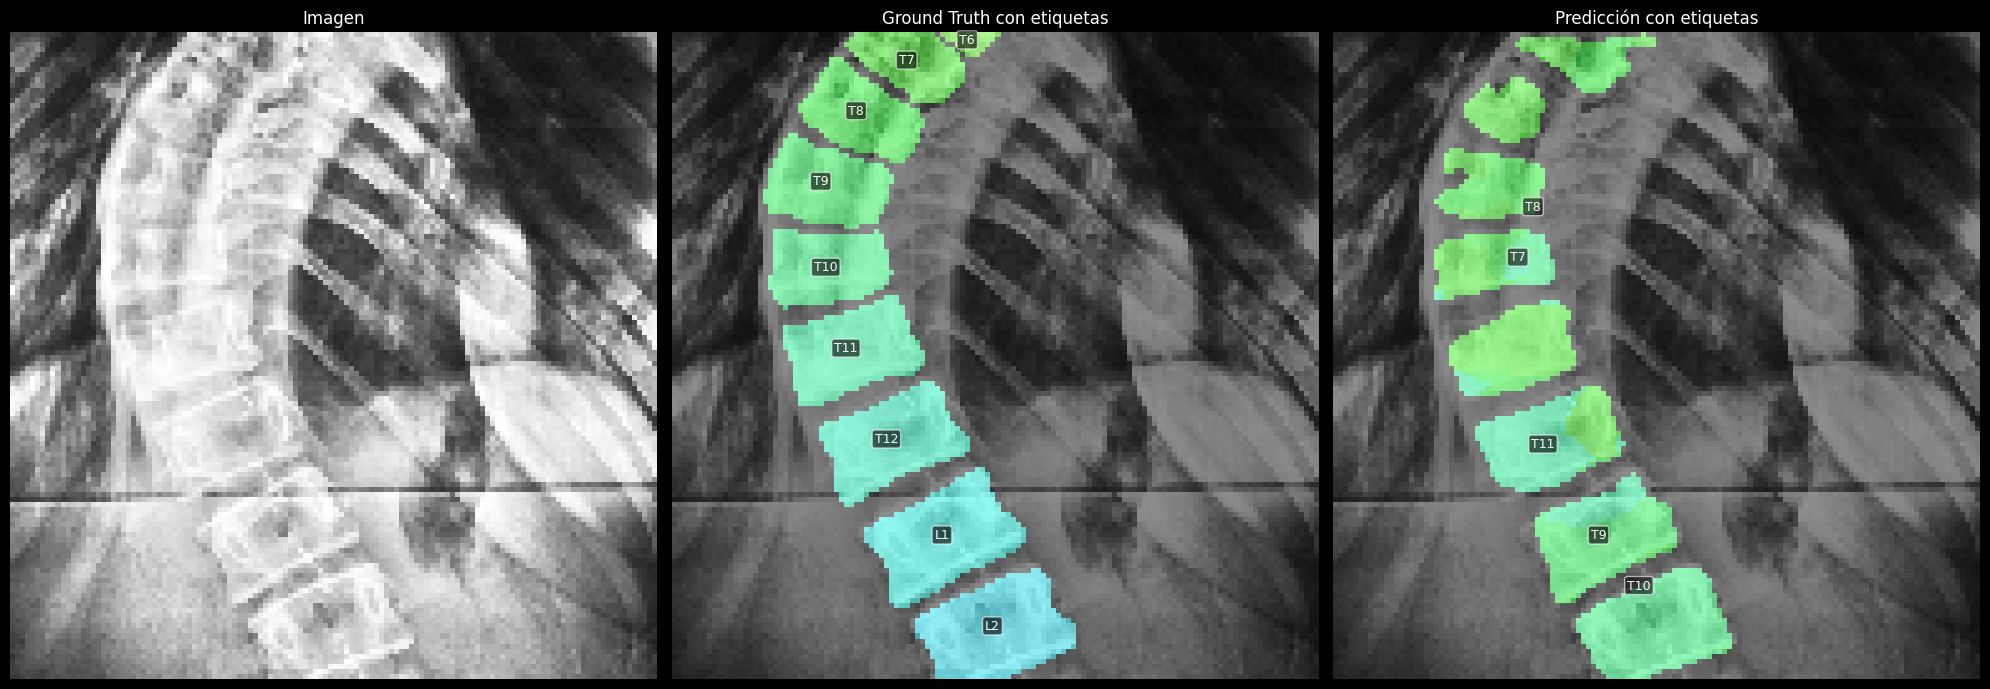

Dice Score promedio: 0.5149
Dice Score por clase: 
background 0.9743
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 0.1159
T8 0.0000
T9 0.0000
T10 0.1181
T11 0.0558
T12 0.0048
L1 0.0000
L2 0.0000
L3 1.0000
L4 1.0000
L5 1.0000
0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg
tensor([[[[  4.2734,   5.9180,   5.7773,  ...,   4.4570,   4.7930,   3.5117],
          [  5.6172,   7.4219,   7.0430,  ...,   5.7188,   6.0430,   4.4766],
          [  5.5742,   7.3984,   6.8086,  ...,   5.4570,   5.7461,   4.2266],
          ...,
          [  5.1211,   6.6367,   6.1172,  ...,   4.8125,   4.8359,   3.4336],
          [  5.4023,   6.9844,   6.4375,  ...,   5.5000,   5.4062,   3.8047],
          [  3.3516,   4.9258,   4.5938,  ...,   4.2734,   4.1602,   3.2734]],

         [[ -3.5547,  -5.6680,  -6.1875,  ...,  -8.1250,  -8.0391,  -5.5195],
          [ -5.3555,  -8.0625,  -8.5781,  ..., -11.7422, -11.5312,  -8.0312],
          [ -5.5859,  -8

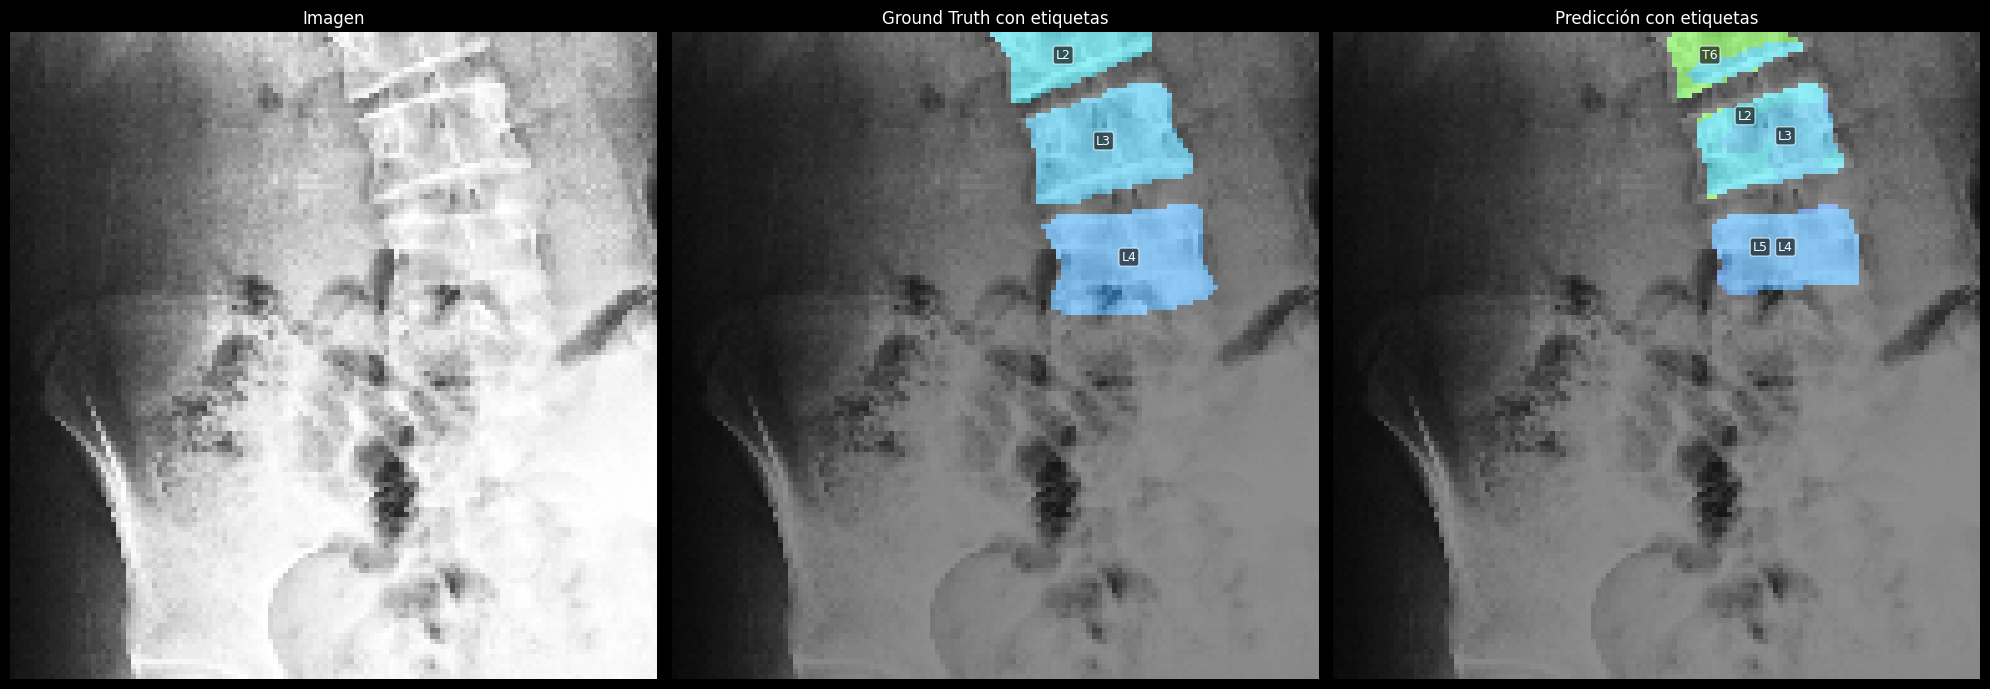

Dice Score promedio: 0.7017
Dice Score por clase: 
background 0.9884
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 0.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 0.0000
L2 0.2711
L3 0.5747
L4 0.7964
L5 0.0000


In [78]:
import random
# Seleccionar un índice aleatorio del dataset de test
idx = 0
# print(idx)
for patch_idx in range(NUM_PATCHES):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = patch_idx,
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )

In [ ]:
import random
# Seleccionar un índice aleatorio del dataset de test
# idx = random.randint(0, len(test_dataset) - 1)
# print(idx)
for idx in range(len(test_dataset)):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = random.randint(0, NUM_PATCHES-1),
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )